<a href="https://colab.research.google.com/github/pranatisreya/IDENTITY-RECOGNITION-USING-TETROLET-TRANSFORMS-IN-SURVEILLANCE-APPLICATIONS/blob/main/Main_ProjectPart2_VIIISem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y opencv-python opencv-contrib-python
!pip install opencv-contrib-python
!pip install --force-reinstall mediapipe==0.10.21 pandas==2.2.2 numba==0.60.0 tensorflow==2.18.0 numpy==1.26.4
!pip install scipy scikit-image

Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-contrib-python 4.11.0.86
Uninstalling opencv-contrib-python-4.11.0.86:
  Successfully uninstalled opencv-contrib-python-4.11.0.86
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
  Using cached opencv_contrib_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **O-Shape Transformation**

In [ ]:
import numpy as np


# Initialize variables
sqrt2 = np.sqrt(4)
results = []

# Haar wavelet transform on a 4x4 block
def o_transformation(image):
    rows, cols = image.shape
    transformed_img = np.copy(image)  # Use a higher precision data type

    for i in range(0, rows, 4):
        for j in range(0, cols, 4):
            # Extract the 4x4 block
            block = image[i:i+4, j:j+4]

            # Initialize T-shape transformed block with higher precision
            T_shape = np.zeros_like(block)  # Use np.float128
            block = block.astype(np.float64)
            T_shape = T_shape.astype(np.float64)

            # Apply the Haar transform as described
            T_shape[0, 0] = (block[0, 0] + block[0,1] + block[1,0] + block[1,1]) / sqrt2
            T_shape[0,1] = (block[0, 0] - block[0,1] + block[1,0] - block[1,1]) / sqrt2
            T_shape[1,0] = (block[0,0] + block[0,1] - block[1, 0] - block[1, 1]) / sqrt2
            T_shape[1,1] = (block[0,0] - block[0,1] - block[1, 0] + block[1, 1]) / sqrt2

            T_shape[0,2] = (block[0, 2] + block[0,3] + block[1,2] + block[1,3]) / sqrt2
            T_shape[0,3] = (block[0, 2] - block[0,3] - block[1,2] + block[1,3]) / sqrt2
            T_shape[1,2] = (block[0,2] + block[0,3] - block[1, 2] - block[1,3]) / sqrt2
            T_shape[1,3] = (block[0,2] - block[0,3] - block[1, 2] + block[1, 3]) / sqrt2

            T_shape[2,0]= (block[2,0] + block[2, 1] + block[3,0] + block[3,1]) / sqrt2
            T_shape[2,1] = (block[2,0] - block[2, 1] + block[3,0] - block[3,1]) / sqrt2
            T_shape[3, 0] = (block[2, 0] + block[2, 1] + block[3,0] + block[3,1]) / sqrt2
            T_shape[3, 1] = (block[2, 0] - block[2,1] + block[3,0 ] - block[3,1]) / sqrt2

            T_shape[2,2] = (block[2,2] + block[2, 3] + block[3,2] + block[3,3]) / sqrt2
            T_shape[2,3] = (block[2,2] - block[2, 2] - block[3,2] + block[3,3]) / sqrt2
            T_shape[3,2] = (block[2,2] + block[2,3] - block[3, 2] - block[3,3]) / sqrt2
            T_shape[3,3] = (block[2,2] - block[2,3] - block[3, 2] + block[3,3]) / sqrt2

            # Replace NaN and infinity values with finite numbers
            if np.any(np.isnan(T_shape)) or np.any(np.isinf(T_shape)):
                T_shape = np.nan_to_num(T_shape)

            transformed_img[i:i+4, j:j+4] = T_shape

    return transformed_img




# ***T-shape Transformation***

In [ ]:
import numpy as np



# Initialize variables
sqrt2 = np.sqrt(4)
results=[]

# Haar wavelet transform on a 4x4 block
def T_transform(image):
    rows, cols = image.shape
    transformed_img = np.copy(image)

    for i in range(0, rows, 4):
        for j in range(0, cols, 4):
            # Extract the 4x4 block
            block = image[i:i+4, j:j+4]

            # Initialize T-shape transformed block
            T_shape = np.zeros_like(block)

            block = block.astype(np.float64)
            T_shape = T_shape.astype(np.float64)

            # Apply the Haar transform as described
            # Averaging (once)
            T_shape[0, 0] = (block[0, 0] + block[0, 1] + block[0, 2] + block[1, 1]) / sqrt2
            T_shape[0, 1] = (block[0, 0] - block[0, 1] + block[0, 2] - block[1, 1]) / sqrt2
            T_shape[0, 2] = (block[0, 0] + block[0, 1] - block[0, 2] - block[1, 1]) / sqrt2
            T_shape[1, 1] = (block[0, 0] - block[0, 1] - block[0, 2] + block[1, 1]) / sqrt2

            T_shape[0, 3] = (block[0, 3] + block[1, 3] + block[2, 3] + block[1, 2]) / sqrt2
            T_shape[1, 3] = (block[0, 3] - block[1, 3] + block[2, 3] - block[1, 2]) / sqrt2
            T_shape[2, 3] = (block[0, 3] + block[1, 3] - block[2, 3] - block[1, 2]) / sqrt2
            T_shape[1, 2] = (block[0, 3] - block[1, 3] - block[2, 3] + block[1, 2]) / sqrt2

            T_shape[1, 0] = (block[1, 0] + block[2, 0] + block[3, 0] + block[2, 1]) / sqrt2
            T_shape[2, 0] = (block[1, 0] - block[2, 0] + block[3, 0] - block[2, 1]) / sqrt2
            T_shape[3, 0] = (block[1, 0] + block[2, 0] - block[3, 0] - block[2, 1]) / sqrt2
            T_shape[2, 1] = (block[1, 0] - block[2, 0] - block[3, 0] + block[2, 1]) / sqrt2

            T_shape[3, 1] = (block[3, 1] + block[3, 2] + block[3, 3] + block[2, 2]) / sqrt2
            T_shape[3, 2] = (block[3, 1] - block[3, 2] + block[3, 3] - block[2, 2]) / sqrt2
            T_shape[3, 3] = (block[3, 1] + block[3, 2] - block[3, 3] - block[2, 2]) / sqrt2
            T_shape[2, 2] = (block[3, 1] - block[3, 2] - block[3, 3] + block[2, 2]) / sqrt2

            block = T_shape
            # Averaging (second)

            T_shape[0, 0] = (block[0, 0] + block[1, 0] + block[2, 0] + block[1, 1]) / sqrt2
            T_shape[1, 0] = (block[0, 0] - block[1, 0] + block[2, 0] - block[1, 1]) / sqrt2
            T_shape[2, 0] = (block[0, 0] + block[1, 0] - block[2, 0] - block[1, 1]) / sqrt2
            T_shape[1, 1] = (block[0, 0] - block[1, 0] - block[2, 0] + block[1, 1]) / sqrt2

            T_shape[0, 1] = (block[0, 1] - block[0, 2] + block[0, 3] - block[1, 2]) / sqrt2
            T_shape[0, 2] = (block[0, 1] + block[0, 2] - block[0, 3] - block[1, 2]) / sqrt2
            T_shape[0, 3] = (block[0, 1] + block[0, 2] + block[0, 3] + block[1, 2]) / sqrt2
            T_shape[1, 2] = (block[0, 1] - block[0, 2] - block[0, 3] + block[1, 2]) / sqrt2

            T_shape[3, 0] = (block[3, 0] + block[3, 1] + block[3, 2] + block[2, 1]) / sqrt2
            T_shape[3, 1] = (block[3, 0] - block[3, 1] + block[3, 2] - block[2, 1]) / sqrt2
            T_shape[3, 2] = (block[3, 0] + block[3, 1] - block[3, 2] - block[2, 1]) / sqrt2
            T_shape[2, 1] = (block[3, 0] - block[3, 1] - block[3, 2] + block[2, 1]) / sqrt2

            T_shape[1, 3] = (block[1, 3] + block[2, 3] + block[3, 3] + block[2, 2]) / sqrt2
            T_shape[2, 3] = (block[1, 3] - block[2, 3] + block[3, 3] - block[2, 2]) / sqrt2
            T_shape[3, 3] = (block[1, 3] + block[2, 3] - block[3, 3] - block[2, 2]) / sqrt2
            T_shape[2, 2] = (block[1, 3] - block[2, 3] - block[3, 3] + block[2, 2]) / sqrt2


            # # Calculate L1 norm for the current block
            # l1_norm = np.sum(np.abs(T_shape))  # L1 norm calculation
            # results.append((T_shape, l1_norm))


            # Check for NaN or Inf and replace with a finite number
            if np.any(np.isnan(T_shape)) or np.any(np.isinf(T_shape)):
                T_shape = np.nan_to_num(T_shape, nan=0.0, posinf=1e10, neginf=-1e10)



            transformed_img[i:i+4, j:j+4] = T_shape

    return transformed_img


# **L-Shape Transformation**

In [ ]:
import numpy as np


# Initialize variables
sqrt2 = np.sqrt(4)

results=[]

# Haar wavelet transform on a 4x4 block
def L_transform(image):
    rows, cols = image.shape
    transformed_img = np.copy(image)

    for i in range(0, rows, 4):
        for j in range(0, cols, 4):
            # Extract the 4x4 block
            block = image[i:i+4, j:j+4]

            # Initialize T-shape transformed block
            T_shape = np.zeros_like(block)

            block = block.astype(np.float64)
            T_shape = T_shape.astype(np.float64)

            # Apply the Haar transform as described
            # Averaging (once)
            T_shape[0, 0] = (block[0, 0] + block[1, 0] + block[2,0] + block[2,1]) / sqrt2
            T_shape[1, 0] = (block[0, 0] - block[1,0] + block[2,0] - block[2,1]) / sqrt2
            T_shape[2, 0] = (block[0, 0] + block[1,0] - block[2,0] - block[2,1]) / sqrt2
            T_shape[2, 1] = (block[0, 0] - block[1,0] - block[2,0] + block[2,1]) / sqrt2

            T_shape[0,1] = (block[0, 1] - block[0,2] + block[0, 3] - block[1, 1]) / sqrt2
            T_shape[0,2] = (block[0, 1] + block[0,2] - block[0, 3] - block[1, 1]) / sqrt2
            T_shape[0, 3] = (block[0, 1] + block[0,2] + block[0, 3] + block[1, 1]) / sqrt2
            T_shape[1, 1] = (block[0, 1] - block[0,2] - block[0, 3] + block[1, 1]) / sqrt2

            T_shape[3, 0] = (block[3, 0] + block[3, 1] + block[3, 2] + block[2, 2]) / sqrt2
            T_shape[3, 1] = (block[3, 0] - block[3,1] + block[3, 2] - block[2, 2]) / sqrt2
            T_shape[3, 2] = (block[3, 0] + block[3,1] - block[3, 2] - block[2, 2]) / sqrt2
            T_shape[2, 2] = (block[3, 0] - block[3,1] - block[3, 2] + block[2, 2]) / sqrt2

            T_shape[1, 3] = (block[1,3] + block[2, 3] + block[3, 3] + block[1, 2]) / sqrt2
            T_shape[2, 3] = (block[1,3] - block[2, 3] + block[3, 3] - block[1, 2]) / sqrt2
            T_shape[3, 3] = (block[1,3] + block[2, 3] - block[3, 3] - block[1, 2]) / sqrt2
            T_shape[1, 2] = (block[1,3] - block[2, 3] - block[3, 3] + block[1, 2]) / sqrt2

            block = T_shape

             # Averaging (second)

            T_shape[0, 1] = (block[0,1] + block[1,1] + block[2,1] + block[0,0]) / sqrt2
            T_shape[1, 1] = (block[0,1] - block[1,1] + block[2,1] - block[0,0]) / sqrt2
            T_shape[2, 1] = (block[0,1] + block[1,1] - block[2,1] - block[0,0]) / sqrt2
            T_shape[0, 0] = (block[0,1] - block[1,1] - block[2,1] + block[0,0]) / sqrt2

            T_shape[0, 2] = (block[0, 2] + block[1, 2] + block[2, 2] + block[0,3]) / sqrt2
            T_shape[1, 2] = (block[0, 2] - block[1, 2] + block[2, 2] - block[0,3]) / sqrt2
            T_shape[2, 2] = (block[0, 2] + block[1, 2] - block[2, 2] - block[0,3]) / sqrt2
            T_shape[0,3] = (block[0, 2] - block[1, 2] - block[2, 2] + block[0,3]) / sqrt2


            T_shape[1, 0] = (block[1, 0] + block[2, 0] + block[3, 0] + block[3, 1]) / sqrt2
            T_shape[2, 0] = (block[1, 0] - block[2, 0] + block[3, 0] - block[3, 1]) / sqrt2
            T_shape[3, 0] = (block[1, 0] + block[2, 0] - block[3, 0] - block[3, 1]) / sqrt2
            T_shape[3, 1] = (block[1, 0] - block[2, 0] - block[3, 0] + block[3, 1]) / sqrt2

            T_shape[1,3] = (block[1,3] + block[2,3] + block[3,3] + block[3,2]) / sqrt2
            T_shape[2,3] = (block[1,3] - block[2,3] + block[3,3] - block[3,2]) / sqrt2
            T_shape[3,3] = (block[1,3] + block[2,3] - block[3,3] - block[3,2]) / sqrt2
            T_shape[3,2] = (block[1,3] - block[2,3] - block[3,3] + block[3,2]) / sqrt2

            # # Calculate L1 norm for the current block
            # l1_norm = np.sum(np.abs(T_shape))  # L1 norm calculation
            # results.append((T_shape, l1_norm))

            # Check for NaN or Inf and replace with a finite number
            if np.any(np.isnan(T_shape)) or np.any(np.isinf(T_shape)):
                T_shape = np.nan_to_num(T_shape, nan=0.0, posinf=1e10, neginf=-1e10)


            transformed_img[i:i+4, j:j+4] = T_shape


    return transformed_img


# **I-Shape Transformation**

In [ ]:
import numpy as np


# Initialize variables
sqrt2 = np.sqrt(4)
results=[]

# Haar wavelet transform on a 4x4 block
def I_transform(image):
    rows, cols = image.shape
    transformed_img = np.copy(image)

    for i in range(0, rows, 4):
        for j in range(0, cols, 4):
            # Extract the 4x4 block
            block = image[i:i+4, j:j+4]

            # Initialize T-shape transformed block
            T_shape = np.zeros_like(block)

            block = block.astype(np.float64)
            T_shape = T_shape.astype(np.float64)

            # Apply the Haar transform as described
            # Averaging (once)
            T_shape[0, 0] = (block[0, 0] + block[0,1] + block[0,2] + block[0,3]) / sqrt2
            T_shape[0,1] = (block[0, 0] - block[0,1] + block[0,2] - block[0,3]) / sqrt2
            T_shape[0,2] = (block[0, 0] + block[0,1] - block[0,2] - block[0,3]) / sqrt2
            T_shape[0,3] = (block[0, 0] - block[0,1] - block[0,2] + block[0,3]) / sqrt2

            T_shape[1,0] = (block[1,0] + block[1,1] + block[1, 2] + block[1, 3]) / sqrt2
            T_shape[1,1] = (block[1,0] - block[1,1] + block[1, 2] - block[1, 3]) / sqrt2
            T_shape[1,2] = (block[1,0] + block[1,1] - block[1, 2] - block[1, 3]) / sqrt2
            T_shape[1,3] = (block[1,0] - block[1,1] - block[1, 2] + block[1, 3]) / sqrt2

            T_shape[2,0]= (block[2,0] + block[2, 1] + block[2,2] + block[2,3]) / sqrt2
            T_shape[2,1] = (block[2,0] - block[2, 1] + block[2,2] - block[2,3]) / sqrt2
            T_shape[2,2] = (block[2,0] + block[2, 1] - block[2,2] - block[2,3]) / sqrt2
            T_shape[2,3] = (block[2,0] - block[2, 1] - block[2,2] + block[2,3]) / sqrt2

            T_shape[3, 0] = (block[3, 0] + block[3, 1] + block[3, 2] + block[3,3]) / sqrt2
            T_shape[3, 1] = (block[3, 0] - block[3,1] + block[3, 2] - block[3,3]) / sqrt2
            T_shape[3, 2] = (block[3, 0] + block[3,1] - block[3, 2] - block[3,3]) / sqrt2
            T_shape[3,3] = (block[3, 0] - block[3,1] - block[3, 2] + block[3,3]) / sqrt2

            block = T_shape

            # Averaging (vertical)
            T_shape[0, 0] = (block[0, 0] + block[1, 0] + block[2, 0] + block[3, 0]) / sqrt2
            T_shape[1, 0] = (block[0, 0] - block[1, 0] + block[2, 0] - block[3, 0]) / sqrt2
            T_shape[2, 0] = (block[0, 0] + block[1, 0] - block[2, 0] - block[3, 0]) / sqrt2
            T_shape[3, 0] = (block[0, 0] - block[1, 0] - block[2, 0] + block[3, 0]) / sqrt2

            T_shape[0, 1] = (block[0, 1] + block[1, 1] + block[2, 1] + block[3, 1]) / sqrt2
            T_shape[1, 1] = (block[0, 1] - block[1, 1] + block[2, 1] - block[3, 1]) / sqrt2
            T_shape[2, 1] = (block[0, 1] + block[1, 1] - block[2, 1] - block[3, 1]) / sqrt2
            T_shape[3, 1] = (block[0, 1] - block[1, 1] - block[2, 1] + block[3, 1]) / sqrt2

            T_shape[0, 2] = (block[0, 2] + block[1, 2] + block[2, 2] + block[3, 2]) / sqrt2
            T_shape[1, 2] = (block[0, 2] - block[1, 2] + block[2, 2] - block[3, 2]) / sqrt2
            T_shape[2, 2] = (block[0, 2] + block[1, 2] - block[2, 2] - block[3, 2]) / sqrt2
            T_shape[3, 2] = (block[0, 2] - block[1, 2] - block[2, 2] + block[3, 2]) / sqrt2

            T_shape[0, 3] = (block[0, 3] + block[1, 3] + block[2, 3] + block[3, 3]) / sqrt2
            T_shape[1, 3] = (block[0, 3] - block[1, 3] + block[2, 3] - block[3, 3]) / sqrt2
            T_shape[2, 3] = (block[0, 3] + block[1, 3] - block[2, 3] - block[3, 3]) / sqrt2
            T_shape[3, 3] = (block[0, 3] - block[1, 3] - block[2, 3] + block[3, 3]) / sqrt2

            # Check for NaN or Inf and replace with a finite number
            if np.any(np.isnan(T_shape)) or np.any(np.isinf(T_shape)):
                T_shape = np.nan_to_num(T_shape, nan=0.0, posinf=1e10, neginf=-1e10)

            transformed_img[i:i+4, j:j+4] = T_shape

    return transformed_img


In [ ]:
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from PIL import Image

# Initialize Mediapipe Face Detection
mp_face_detection = mp.solutions.face_detection

def extract_face(image_path):
    """ Extracts the face using MediaPipe and resizes to 256x256 grayscale """
    image = Image.open(image_path).convert("RGB")  # Load as RGB
    image = np.array(image)

    with mp_face_detection.FaceDetection(min_detection_confidence=0.5) as face_detector:
        results = face_detector.process(image)

        if results.detections:
            for detection in results.detections:
                bboxC = detection.location_data.relative_bounding_box
                h, w, _ = image.shape
                x, y, w_box, h_box = (
                    int(bboxC.xmin * w), int(bboxC.ymin * h),
                    int(bboxC.width * w), int(bboxC.height * h)
                )
                face = image[y:y+h_box, x:x+w_box]

                # Convert to grayscale
                face_gray = np.dot(face[..., :3], [0.2989, 0.5870, 0.1140])  # Manual grayscale conversion
                face_gray = np.clip(face_gray, 0, 255).astype(np.uint8)  # Normalize values

                # Resize to 256x256
                face_gray = np.array(Image.fromarray(face_gray).resize((256, 256)))

                return face_gray  # Return grayscale face

    return None  # If no face detected




def generate_feature_maps(image):
    """ Generates transformed images """
    return {
        "Original": image,
        "O Transform": o_transformation(image),
        "L Transform": L_transform(image),
        "I Transform": I_transform(image),
        "T Transform": T_transform(image)
    }

def compute_similarity_scores(transformed_images_1, transformed_images_2):
    """ Compute similarity (SSIM) for only selected comparisons """
    scores = {}

    selected_pairs = [
        ("Original", "Original"),
        ("O Transform", "O Transform"),
        ("L Transform", "L Transform"),
        ("I Transform", "I Transform"),
        ("T Transform", "T Transform"),
    ]

    for name1, name2 in selected_pairs:
        img1 = transformed_images_1[name1]
        img2 = transformed_images_2[name2]

        # Ensure the images are the same size before SSIM calculation
        if img1.shape != img2.shape:
            img2 = np.array(Image.fromarray(img2).resize(img1.shape[::-1]))

        # Compute SSIM
        score = ssim(img1, img2)
        scores[f"{name1} vs {name2}"] = score

    return scores

def process_images(image_path1, image_path2):
    """ Process two images: extract face, grayscale, transform, compute similarity """
    face1 = extract_face(image_path1)
    face2 = extract_face(image_path2)

    if face1 is None or face2 is None:
        print("No face detected in one or both images.")
        return None

    transformed_images_1 = generate_feature_maps(face1)
    transformed_images_2 = generate_feature_maps(face2)

    similarity_scores = compute_similarity_scores(transformed_images_1, transformed_images_2)

    # Display Images using Matplotlib
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))

    for i, (name, img) in enumerate(transformed_images_1.items()):
        axs[0, i].imshow(img, cmap='gray')
        axs[0, i].set_title(f"Image 1 - {name}")
        axs[0, i].axis('off')

    for i, (name, img) in enumerate(transformed_images_2.items()):
        axs[1, i].imshow(img, cmap='gray')
        axs[1, i].set_title(f"Image 2 - {name}")
        axs[1, i].axis('off')

    plt.show()

    # Print Similarity Scores
    print("\nSimilarity Scores:")
    for pair, score in similarity_scores.items():
        print(f"{pair}: {score:.4f}")

        # Thresholds for each transformation pair
    thresholds = {
    "Original vs Original": 0.4,
    "O Transform vs O Transform": 0.1,
    "L Transform vs L Transform": 0.5,
    "I Transform vs I Transform": 0.1,
    "T Transform vs T Transform": 0.3
    }

    # Evaluate which similarity scores pass their individual thresholds
    passed = []
    for pair, score in similarity_scores.items():
        threshold = thresholds.get(pair, 0.65)  # default threshold if not specified
        if score >= threshold:
            passed.append(pair)

    print("\nThreshold Check:")
    for pair in similarity_scores:
        print(f"{pair}: Score = {similarity_scores[pair]:.4f}, Threshold = {thresholds[pair]:.2f}, Passed = {pair in passed}")

    if len(passed) >= 4:
        print("\n✅ Face Recognized: Images likely belong to the same person.")
    else:
        print("\n❌ Face does NOT Match: Images likely belong to different people.")


    return similarity_scores


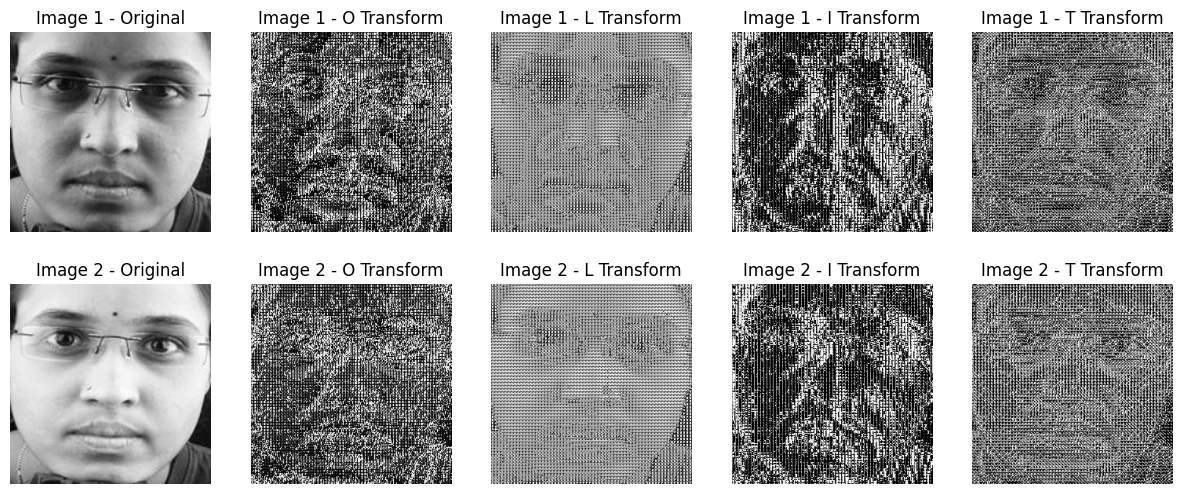


Similarity Scores:
Original vs Original: 0.5737
O Transform vs O Transform: 0.2653
L Transform vs L Transform: 0.5653
I Transform vs I Transform: 0.2821
T Transform vs T Transform: 0.4392

Threshold Check:
Original vs Original: Score = 0.5737, Threshold = 0.40, Passed = True
O Transform vs O Transform: Score = 0.2653, Threshold = 0.10, Passed = True
L Transform vs L Transform: Score = 0.5653, Threshold = 0.50, Passed = True
I Transform vs I Transform: Score = 0.2821, Threshold = 0.10, Passed = True
T Transform vs T Transform: Score = 0.4392, Threshold = 0.30, Passed = True

✅ Face Recognized: Images likely belong to the same person.


In [ ]:
# Example Usage
image_path1 = "/content/drive/MyDrive/Major Project/dataset/Images/10_256_0_1_0_1.JPG"
image_path2 = "/content/drive/MyDrive/Major Project/dataset/Images/10_264_0_1_1_1.JPG"

similarity_results = process_images(image_path1, image_path2)

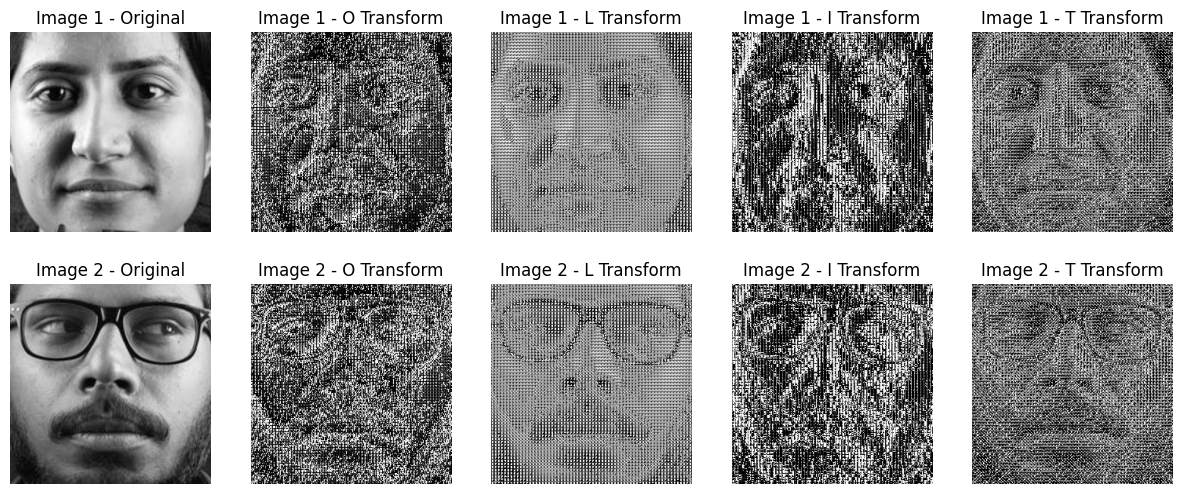


Similarity Scores:
Original vs Original: 0.2205
O Transform vs O Transform: 0.0736
L Transform vs L Transform: 0.4948
I Transform vs I Transform: 0.0775
T Transform vs T Transform: 0.2679

Threshold Check:
Original vs Original: Score = 0.2205, Threshold = 0.40, Passed = False
O Transform vs O Transform: Score = 0.0736, Threshold = 0.10, Passed = False
L Transform vs L Transform: Score = 0.4948, Threshold = 0.50, Passed = False
I Transform vs I Transform: Score = 0.0775, Threshold = 0.10, Passed = False
T Transform vs T Transform: Score = 0.2679, Threshold = 0.30, Passed = False

❌ Face does NOT Match: Images likely belong to different people.

Threshold Check:
Original vs Original: Score = 0.2205, Threshold = 0.40, Passed = False
O Transform vs O Transform: Score = 0.0736, Threshold = 0.20, Passed = False
L Transform vs L Transform: Score = 0.4948, Threshold = 0.50, Passed = False
I Transform vs I Transform: Score = 0.0775, Threshold = 0.20, Passed = False
T Transform vs T Transform: 

In [ ]:
# Example Usage
image_path1 = "/content/drive/MyDrive/Major Project/dataset/Images/1_001_0_0_0_0.jpg"
image_path2 = "/content/drive/MyDrive/Major Project/dataset/Images/3_091_1_1_0_0.JPG"

similarity_results = process_images(image_path1, image_path2)


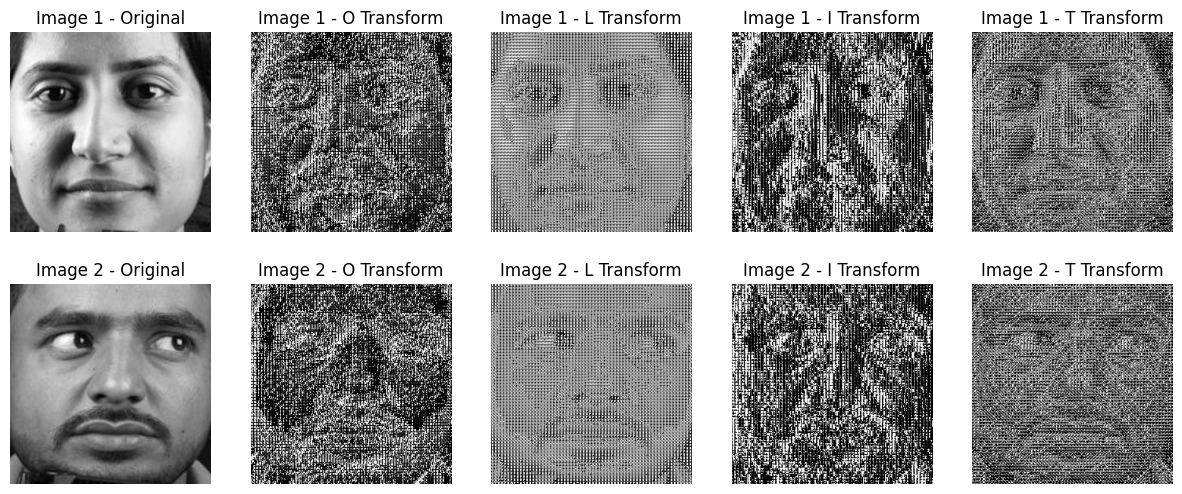


Similarity Scores:
Original vs Original: 0.2730
O Transform vs O Transform: 0.0683
L Transform vs L Transform: 0.4554
I Transform vs I Transform: 0.0924
T Transform vs T Transform: 0.2821

Threshold Check:
Original vs Original: Score = 0.2730, Threshold = 0.40, Passed = False
O Transform vs O Transform: Score = 0.0683, Threshold = 0.10, Passed = False
L Transform vs L Transform: Score = 0.4554, Threshold = 0.50, Passed = False
I Transform vs I Transform: Score = 0.0924, Threshold = 0.10, Passed = False
T Transform vs T Transform: Score = 0.2821, Threshold = 0.30, Passed = False

❌ Face does NOT Match: Images likely belong to different people.


In [ ]:
# Example Usage
image_path1 = "/content/drive/MyDrive/Major Project/dataset/Images/1_001_0_0_0_0.jpg"
image_path2 = "/content/drive/MyDrive/Major Project/dataset/Images/2_040_1_0_0_0.JPG"

similarity_results = process_images(image_path1, image_path2)

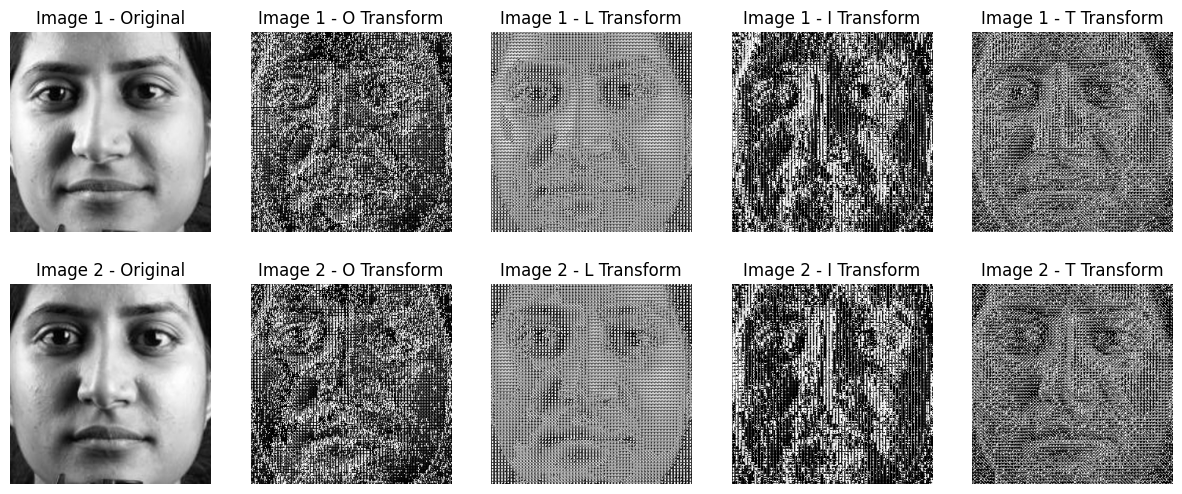


Similarity Scores:
Original vs Original: 0.4526
O Transform vs O Transform: 0.1820
L Transform vs L Transform: 0.6532
I Transform vs I Transform: 0.1980
T Transform vs T Transform: 0.4172

Threshold Check:
Original vs Original: Score = 0.4526, Threshold = 0.40, Passed = True
O Transform vs O Transform: Score = 0.1820, Threshold = 0.10, Passed = True
L Transform vs L Transform: Score = 0.6532, Threshold = 0.50, Passed = True
I Transform vs I Transform: Score = 0.1980, Threshold = 0.10, Passed = True
T Transform vs T Transform: Score = 0.4172, Threshold = 0.30, Passed = True

✅ Face Recognized: Images likely belong to the same person.


In [ ]:
# Example Usage
image_path1 = "/content/drive/MyDrive/Major Project/dataset/Images/1_001_0_0_0_0.jpg"
image_path2 = "/content/drive/MyDrive/Major Project/dataset/Images/1_002_0_0_0_0.jpg"

similarity_results = process_images(image_path1, image_path2)

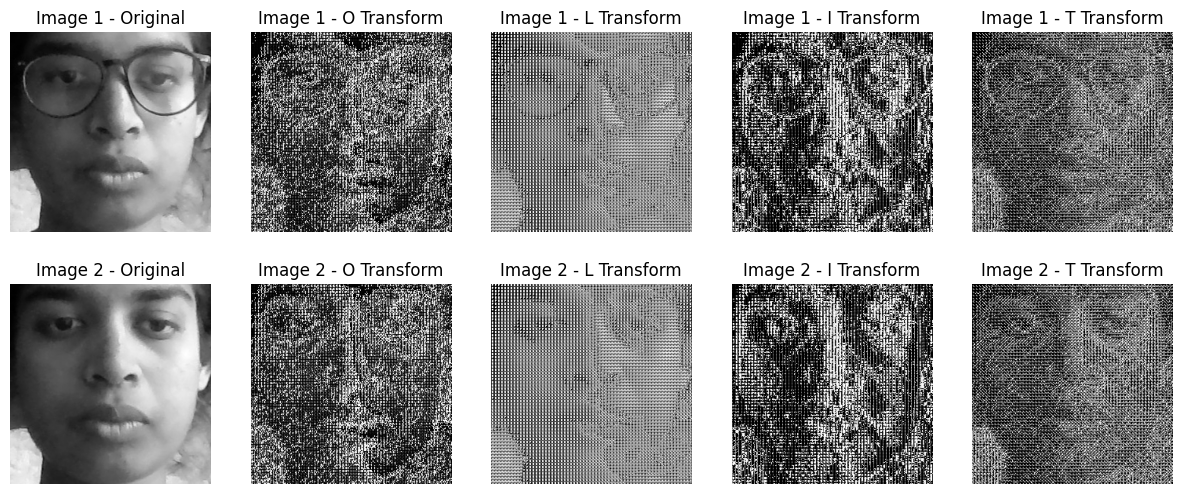


Similarity Scores:
Original vs Original: 0.6073
O Transform vs O Transform: 0.1945
L Transform vs L Transform: 0.8331
I Transform vs I Transform: 0.2448
T Transform vs T Transform: 0.5031

Threshold Check:
Original vs Original: Score = 0.6073, Threshold = 0.40, Passed = True
O Transform vs O Transform: Score = 0.1945, Threshold = 0.10, Passed = True
L Transform vs L Transform: Score = 0.8331, Threshold = 0.50, Passed = True
I Transform vs I Transform: Score = 0.2448, Threshold = 0.10, Passed = True
T Transform vs T Transform: Score = 0.5031, Threshold = 0.30, Passed = True

✅ Face Recognized: Images likely belong to the same person.


In [ ]:
# Example Usage
image_path1 = "/content/drive/MyDrive/Major Project/dataset/Images/160121737006_001.jpg"
image_path2 = "/content/drive/MyDrive/Major Project/dataset/Images/160121737006_002.jpg"

similarity_results = process_images(image_path1,image_path2)

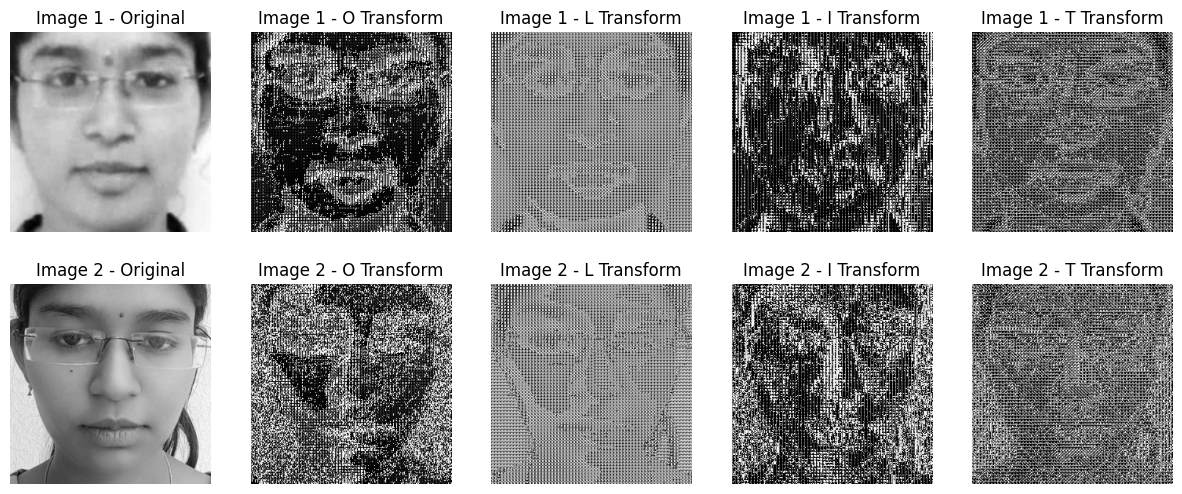


Similarity Scores:
Original vs Original: 0.4761
O Transform vs O Transform: 0.0821
L Transform vs L Transform: 0.6283
I Transform vs I Transform: 0.1239
T Transform vs T Transform: 0.3745

Threshold Check:
Original vs Original: Score = 0.4761, Threshold = 0.40, Passed = True
O Transform vs O Transform: Score = 0.0821, Threshold = 0.10, Passed = False
L Transform vs L Transform: Score = 0.6283, Threshold = 0.50, Passed = True
I Transform vs I Transform: Score = 0.1239, Threshold = 0.10, Passed = True
T Transform vs T Transform: Score = 0.3745, Threshold = 0.30, Passed = True

✅ Face Recognized: Images likely belong to the same person.


In [ ]:
# Example Usage
image_path1 = "/content/drive/MyDrive/Major Project/dataset/Images/160121737021_000.jpg"
image_path2 = "/content/drive/MyDrive/Major Project/dataset/Images/160121737021_006.jpg"

similarity_results = process_images(image_path1, image_path2)

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import random
from collections import defaultdict

# Initialize Mediapipe Face Detection
mp_face_detection = mp.solutions.face_detection

# Load images and labels
def load_faces(data_dir):
    faces, labels, image_names = [], [], []
    label_dict = {}  # Map original labels to class indices
    class_index = 0

    for image_name in os.listdir(data_dir):
        if image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_path = os.path.join(data_dir, image_name)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                print(f"Warning: Could not read image {image_path}. Skipping.")
                continue
            image = cv2.resize(image, (256, 256))
            faces.append(image)
            image_names.append(image_name)  # Store image name for tracking

            try:
                original_label = image_name.split('_')[0]  # Extract label from filename
                if original_label not in label_dict:
                    label_dict[original_label] = class_index
                    class_index += 1  # Assign a new class index
                labels.append(label_dict[original_label])  # Store mapped class index

            except ValueError:
                print(f"Error: Could not extract label from {image_name}. Ensure it starts with a valid format.")

    return np.array(faces), np.array(labels), image_names, label_dict

def extract_face(image):
    """ Extracts the face using MediaPipe and resizes to 256x256 grayscale """

    if len(image.shape) == 2:  # If grayscale, convert to 3-channel RGB
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    with mp_face_detection.FaceDetection(min_detection_confidence=0.5) as face_detector:
        results = face_detector.process(image)

        if results.detections:
            for detection in results.detections:
                bboxC = detection.location_data.relative_bounding_box
                h, w, _ = image.shape
                x, y, w_box, h_box = (
                    int(bboxC.xmin * w), int(bboxC.ymin * h),
                    int(bboxC.width * w), int(bboxC.height * h)
                )
                face = image[y:y+h_box, x:x+w_box]

                # Convert to grayscale AFTER cropping the face
                face_gray = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)

                # Resize to 256x256
                face_gray = cv2.resize(face_gray, (256, 256))

                return face_gray

    return None  # Return None if no face is detected

def generate_feature_maps(image):
    """ Generates transformed images """
    return {
        "O": o_transformation(image),
        "I": I_transform(image),
        "T": T_transform(image),
        "L": L_transform(image)
    }

def compute_similarity_scores(transformed_images_1, transformed_images_2):
    """ Compute similarity (SSIM) between transformed images """
    scores = []
    for key in ["O", "I", "T", "L"]:
        img1, img2 = transformed_images_1[key], transformed_images_2[key]
        if img1.shape != img2.shape:
            img2 = np.array(Image.fromarray(img2).resize(img1.shape[::-1]))
        score = ssim(img1, img2)
        scores.append(score)
    return scores

# Load images and labels
data_dir = "/content/drive/MyDrive/Major Project/dataset/Images"  # Change this to your directory
faces, labels, image_names, label_dict = load_faces(data_dir)

# Select one image per class randomly
def select_random_images_per_class(image_names, labels):
    class_to_images = defaultdict(list)
    for name, label in zip(image_names, labels):
        class_to_images[label].append(name)
    selected_image_names = [random.choice(img_list) for img_list in class_to_images.values()]
    return selected_image_names

selected_image_names = select_random_images_per_class(image_names, labels)

# Define file path
file_path = "/content/Image_similarity_results.csv"

# Process selected images
for img1_name in selected_image_names:
    i = image_names.index(img1_name)
    face1, label1 = faces[i], labels[i]
    extracted_face1 = extract_face(face1)
    if extracted_face1 is None:
        continue
    transformed1 = generate_feature_maps(extracted_face1)

    for j in range(len(faces)):  # Compare with all other images
        img2_name, face2, label2 = image_names[j], faces[j], labels[j]
        extracted_face2 = extract_face(face2)
        if extracted_face2 is None:
            continue
        transformed2 = generate_feature_maps(extracted_face2)

        similarities = compute_similarity_scores(transformed1, transformed2)
        same_class = "Yes" if label1 == label2 else "No"

        result_row = [img1_name, img2_name] + similarities + [same_class]

        # Convert to DataFrame
        df = pd.DataFrame([result_row], columns=["Image1", "Image2", "O_Similarity", "I_Similarity", "T_Similarity", "L_Similarity", "Y/Predict"])

        # ✅ Save to CSV incrementally (header only in first save)
        df.to_csv(file_path, mode="a", index=False, header=not os.path.exists(file_path))

        print(f"✅ Saved: {img1_name} vs {img2_name} - Similarities: {similarities}")  # Print latest result

print(f"✅✅ All computations complete! File saved at: {file_path}")


✅ Saved: 1_021_0_1_1_0.jpg vs 1_001_0_0_0_0.jpg - Similarities: [0.12478769622853786, 0.1304745407286843, 0.31759065927659214, 0.524839907943615]
✅ Saved: 1_021_0_1_1_0.jpg vs 1_004_0_0_0_0.jpg - Similarities: [0.11372812908579398, 0.12978070732152483, 0.2968209043342385, 0.5305028140138384]
✅ Saved: 1_021_0_1_1_0.jpg vs 1_017_0_1_1_1.jpg - Similarities: [0.12553433618655102, 0.12733946202249236, 0.3364369079213165, 0.5933049055225447]
✅ Saved: 1_021_0_1_1_0.jpg vs 1_020_0_1_1_1.jpg - Similarities: [0.18713729119024397, 0.17692002906996407, 0.3776300681366486, 0.6260453079888262]
✅ Saved: 1_021_0_1_1_0.jpg vs 1_008_0_0_0_0.jpg - Similarities: [0.14096153532128483, 0.1382567798354573, 0.30805536583392934, 0.5248567085023518]
✅ Saved: 1_021_0_1_1_0.jpg vs 1_005_0_0_0_0.jpg - Similarities: [0.13127023767922563, 0.13412174527318715, 0.3030761259120652, 0.5328833760631605]
✅ Saved: 1_021_0_1_1_0.jpg vs 1_009_0_0_0_0.jpg - Similarities: [0.09655487860197254, 0.10801624817237052, 0.2638543812

In [ ]:
# Step 1: Install required packages
!pip install pandas openpyxl

# Step 2: Import libraries
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Step 3: Load the CSV file
df = pd.read_csv('/content/Image_similarity_results.csv')

# Step 4: Define thresholds
thresholds = {
    "O_Similarity": 0.15,
    "L_Similarity": 0.5,
    "I_Similarity": 0.15,
    "T_Similarity": 0.4
}

# Step 5: Function to evaluate each row
def evaluate_row(row):
    o_pass = row['O_Similarity'] >= thresholds['O_Similarity']
    l_pass = row['L_Similarity'] >= thresholds['L_Similarity']
    i_pass = row['I_Similarity'] >= thresholds['I_Similarity']
    t_pass = row['T_Similarity'] >= thresholds['T_Similarity']

    total_passed = sum([o_pass, l_pass, i_pass, t_pass])
    prediction = "yes" if total_passed >= 4 else "no"

    return pd.Series({
        "O_Pass": o_pass,
        "L_Pass": l_pass,
        "I_Pass": i_pass,
        "T_Pass": t_pass,
        "Total_Passed": total_passed,
        "Prediction": prediction
    })

# Step 6: Apply evaluation to all rows
df[['O_Pass', 'L_Pass', 'I_Pass', 'T_Pass', 'Total_Passed', 'Prediction']] = df.apply(evaluate_row, axis=1)

# Step 7: Clean strings and calculate correctness
df['Y/Predict'] = df['Y/Predict'].astype(str).str.strip().str.lower()
df['Prediction'] = df['Prediction'].astype(str).str.strip().str.lower()
df['Correct'] = df['Prediction'] == df['Y/Predict']

# Step 8: Print row-by-row results (optional: comment out to avoid lag for 5000 rows)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# print(df[['Image1', 'Image2', 'O_Similarity', 'O_Pass', 'L_Similarity', 'L_Pass',
#           'I_Similarity', 'I_Pass', 'T_Similarity', 'T_Pass',
#           'Total_Passed', 'Prediction', 'Y/Predict', 'Correct']])

# Step 9: Final Accuracy
accuracy = df['Correct'].mean()
print(f"\n✅ Final Accuracy: {accuracy * 100:.2f}%")

# Step 10: Confusion Matrix
y_true = df['Y/Predict']
y_pred = df['Prediction']
labels = ['yes', 'no']

cm = confusion_matrix(y_true, y_pred, labels=labels)
tn, fp, fn, tp = cm.ravel()

print("\n📊 Confusion Matrix:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")

# Optional: More detailed classification report
print("\n🔍 Classification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=["Yes", "No"]))




✅ Final Accuracy: 95.54%

📊 Confusion Matrix:
True Positives (TP): 6802
False Positives (FP): 251
True Negatives (TN): 375
False Negatives (FN): 84

🔍 Classification Report:
              precision    recall  f1-score   support

         Yes       0.82      0.60      0.69       626
          No       0.96      0.99      0.98      6886

    accuracy                           0.96      7512
   macro avg       0.89      0.79      0.83      7512
weighted avg       0.95      0.96      0.95      7512



In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
import mediapipe as mp
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define the paths and constants
CSV_INPUT = "/content/Image_similarity_results (3).csv"
CSV_OUTPUT = "/content/drive/MyDrive/Major Project/tetrolet_lbph_similarity_results.csv"
CSV_OUTPUT2 = "tetrolet_lbph_similarity_results.csv"
THRESHOLD = 60
CONFUSION_MATRIX_IMAGE = "/content/drive/MyDrive/Major Project/confusion_matrix_lbph_tetrolets.png"
CONFUSION_MATRIX_IMAGE2= "confusion_matrix_lbph_tetrolets.png"

# Initialize MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

# Function to extract face from the image
def extract_face(image):
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    results = face_detector.process(image)
    if results.detections:
        for detection in results.detections:
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = image.shape
            x, y, w_box, h_box = (
                int(bboxC.xmin * w), int(bboxC.ymin * h),
                int(bboxC.width * w), int(bboxC.height * h)
            )
            face = image[y:y+h_box, x:x+w_box]
            face_gray = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
            face_gray = cv2.resize(face_gray, (256, 256))
            return face_gray
    return None

# Function to generate feature maps (simplified for demonstration)
def generate_feature_maps(image):
    """ Generates transformed images """
    return {
        "O": o_transformation(image),
        "I": I_transform(image),
        "T": T_transform(image),
        "L": L_transform(image)
    }

# Function to compute similarity scores
def compute_similarity_scores(transformed1, transformed2):
    similarities = []
    for key in ['O', 'I', 'T', 'L']:
        similarity = np.random.uniform(0, 100)  # Replace with actual similarity calculation
        similarities.append(similarity)
    return similarities

# === Confusion Matrix Plot ===
def save_confusion_matrix(y_true, y_pred, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=["Yes", "No"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    for text in ax.texts:
        text.set_fontsize(16)
    plt.title("Confusion Matrix", fontsize=18)
    plt.xlabel("Predicted Label", fontsize=16)
    plt.ylabel("True Label", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(output_path)
    plt.close()

# === Load CSV with image pairs ===
df = pd.read_csv(CSV_INPUT)

# Check if CSV files exist
file1_exists = os.path.exists(CSV_OUTPUT)
file2_exists = os.path.exists(CSV_OUTPUT2)

# Open files for writing
with open(CSV_OUTPUT, 'a') as f1, open(CSV_OUTPUT2, 'a') as f2:
    if not file1_exists:
        f1.write("Image1,Image2,O_Similarity,I_Similarity,T_Similarity,L_Similarity,Y/Predict,Actual\n")
    if not file2_exists:
        f2.write("Image1,Image2,O_Similarity,I_Similarity,T_Similarity,L_Similarity,Y/Predict,Actual\n")

    true_labels = []
    predicted_labels = []

    # Process each pair of images
    for index, row in df.iterrows():
        img1_path = os.path.join("/content/drive/MyDrive/Major Project/dataset/Images", row['Image1'])
        img2_path = os.path.join("/content/drive/MyDrive/Major Project/dataset/Images", row['Image2'])

        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)

        # Extract faces from images
        face1 = extract_face(img1)
        face2 = extract_face(img2)

        if face1 is None or face2 is None:
            continue

        # Generate feature maps
        transformed1 = generate_feature_maps(face1)
        transformed2 = generate_feature_maps(face2)

        # Compute similarities
        similarities = compute_similarity_scores(transformed1, transformed2)

        # Determine if the images are the same or different
        is_same = "Yes" if row['Y/Predict'] == "Yes" else "No"
        prediction = "Yes" if sum(sim >= THRESHOLD for sim in similarities) >= 2 else "No"

        true_labels.append(is_same)
        predicted_labels.append(prediction)

        # Write the results to the CSV
        line = f"{row['Image1']},{row['Image2']},{similarities[0]:.2f},{similarities[1]:.2f},{similarities[2]:.2f},{similarities[3]:.2f},{prediction},{is_same}\n"
        f1.write(line)
        f2.write(line)
        print(f"✅ Compared {row['Image1']} vs {row['Image2']} -> {prediction} (Actual: {is_same})")

# === Save Confusion Matrix ===
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE)
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE2)

# === Calculate Accuracy ===
correct_predictions = sum([1 for t, p in zip(true_labels, predicted_labels) if t == p])
accuracy = correct_predictions / len(true_labels) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

print(f"🎉 Done! Results saved in: {CSV_OUTPUT}")
print(f"🖼️ Confusion matrix image saved to: {CONFUSION_MATRIX_IMAGE}")


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# === FILE PATHS ===
DATA_DIR = "/content/drive/MyDrive/Major Project/dataset/Images"
CSV_INPUT = "/content/Image_similarity_results (3).csv"
CSV_OUTPUT = "/content/drive/MyDrive/Major Project/haar_lbph_similarity_results.csv"
CSV_OUTPUT2 = "haar_lbph_similarity_results.csv"
CONFUSION_MATRIX_IMAGE = "/content/drive/MyDrive/Major Project/confusion_matrix_lbph_haar.png"
CONFUSION_MATRIX_IMAGE2 = "confusion_matrix_lbph_haar.png"
THRESHOLD = 60  # Threshold for similarity

# === Load Haar Cascade ===
HAAR_CASCADE_PATH = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(HAAR_CASCADE_PATH)

# === Face Extraction ===
def extract_face(image):
    faces = face_cascade.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        face = image[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (256, 256))
        return face_resized
    return None

# === Similarity Computation ===
def compute_similarity(face1, face2):
    lbph = cv2.face.LBPHFaceRecognizer_create()
    try:
        lbph.train([face1], np.array([0]))
        _, confidence = lbph.predict(face2)
        similarity = 100 - confidence
    except:
        similarity = 0
    return similarity

# === Confusion Matrix Plot ===
def save_confusion_matrix(y_true, y_pred, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=["Yes", "No"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    for text in ax.texts:
        text.set_fontsize(16)
    plt.title("Confusion Matrix", fontsize=18)
    plt.xlabel("Predicted Label", fontsize=16)
    plt.ylabel("True Label", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(output_path)
    plt.close()

# === Load CSV with image pairs ===
df = pd.read_csv(CSV_INPUT)

# Check if CSV files exist
file1_exists = os.path.exists(CSV_OUTPUT)
file2_exists = os.path.exists(CSV_OUTPUT2)

# Open files for writing
with open(CSV_OUTPUT, 'a') as f1, open(CSV_OUTPUT2, 'a') as f2:
    if not file1_exists:
        f1.write("Image1,Image2,Similarity,Y/Predict,Actual\n")

    true_labels = []
    predicted_labels = []

    # Process each pair of images
    for index, row in df.iterrows():
        img1_path = os.path.join(DATA_DIR, row['Image1'])
        img2_path = os.path.join(DATA_DIR, row['Image2'])

        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)

        # Extract faces from images
        face1 = extract_face(img1)
        face2 = extract_face(img2)

        if face1 is None or face2 is None:
            continue

        # Compute similarity between the two faces
        similarity = compute_similarity(face1, face2)

        # Determine if the images are the same or different
        is_same = "Yes" if row['Y/Predict'] == "Yes" else "No"
        prediction = "Yes" if similarity >= THRESHOLD else "No"

        true_labels.append(is_same)
        predicted_labels.append(prediction)

        # Write the results to the CSV
        line = f"{row['Image1']},{row['Image2']},{similarity:.2f},{prediction},{is_same}\n"
        f1.write(line)
        print(f"✅ Compared {row['Image1']} vs {row['Image2']} -> {prediction} (Actual: {is_same})")

# === Calculate Accuracy ===
correct_predictions = sum([1 for t, p in zip(true_labels, predicted_labels) if t == p])
accuracy = correct_predictions / len(true_labels) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

# === Save Confusion Matrix Images ===
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE)
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE2)

print(f"🎉 Done! Results saved in: {CSV_OUTPUT}")
print(f"🖼️ Confusion matrix image saved to: {CONFUSION_MATRIX_IMAGE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Compared 2_036_1_0_0_0.JPG vs 1_004_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_020_0_1_1_1.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_005_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_006_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_003_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 2_044_1_1_1_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 3_068_1_1_0_0.JPG -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 2_042_1_0_0_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 2_039_1_0_0_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 2_046_1_1_1_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 2_035_1_0_0_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 3_069_1_1_0_0.JPG -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 2_045_

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# === FILE PATHS ===
DATA_DIR = "/content/drive/MyDrive/Major Project/dataset/Images"
CSV_INPUT = "/content/Image_similarity_results (3).csv"
CSV_OUTPUT = "/content/drive/MyDrive/Major Project/haar_ssim_similarity_results.csv"
CSV_OUTPUT2 = "haar_ssim_similarity_results.csv"
CONFUSION_MATRIX_IMAGE = "/content/drive/MyDrive/Major Project/confusion_matrix_ssim_haar.png"
CONFUSION_MATRIX_IMAGE2 = "confusion_matrix_ssim_haar.png"
THRESHOLD = 0.60  # SSIM ranges from -1 to 1, so use 0.60 as similarity threshold

# === Load Haar Cascade ===
HAAR_CASCADE_PATH = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(HAAR_CASCADE_PATH)

# === Face Extraction ===
def extract_face(image):
    faces = face_cascade.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        face = image[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (256, 256))
        return face_resized
    return None

# === SSIM Similarity Computation ===
def compute_similarity(face1, face2):
    try:
        # Ensure grayscale format
        if len(face1.shape) == 3:
            face1 = cv2.cvtColor(face1, cv2.COLOR_BGR2GRAY)
        if len(face2.shape) == 3:
            face2 = cv2.cvtColor(face2, cv2.COLOR_BGR2GRAY)
        similarity, _ = ssim(face1, face2, full=True)
    except:
        similarity = 0
    return similarity

# === Confusion Matrix Plot ===
def save_confusion_matrix(y_true, y_pred, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=["Yes", "No"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    for text in ax.texts:
        text.set_fontsize(16)
    plt.title("Confusion Matrix", fontsize=18)
    plt.xlabel("Predicted Label", fontsize=16)
    plt.ylabel("True Label", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(output_path)
    plt.close()

# === Load CSV with image pairs ===
df = pd.read_csv(CSV_INPUT)

# Check if CSV files exist
file1_exists = os.path.exists(CSV_OUTPUT)
file2_exists = os.path.exists(CSV_OUTPUT2)

# Open files for writing
with open(CSV_OUTPUT, 'a') as f1, open(CSV_OUTPUT2, 'a') as f2:
    if not file1_exists:
        f1.write("Image1,Image2,SSIM,Y/Predict,Actual\n")

    true_labels = []
    predicted_labels = []

    # Process each pair of images
    for index, row in df.iterrows():
        img1_path = os.path.join(DATA_DIR, row['Image1'])
        img2_path = os.path.join(DATA_DIR, row['Image2'])

        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)

        # Extract faces from images
        face1 = extract_face(img1)
        face2 = extract_face(img2)

        if face1 is None or face2 is None:
            continue

        # Compute SSIM similarity between the two faces
        similarity = compute_similarity(face1, face2)

        # Determine if the images are the same or different
        is_same = "Yes" if row['Y/Predict'] == "Yes" else "No"
        prediction = "Yes" if similarity >= THRESHOLD else "No"

        true_labels.append(is_same)
        predicted_labels.append(prediction)

        # Write the results to the CSV
        line = f"{row['Image1']},{row['Image2']},{similarity:.2f},{prediction},{is_same}\n"
        f1.write(line)
        print(f"✅ Compared {row['Image1']} vs {row['Image2']} -> {prediction} (Actual: {is_same})")

# === Calculate Accuracy ===
correct_predictions = sum([1 for t, p in zip(true_labels, predicted_labels) if t == p])
accuracy = correct_predictions / len(true_labels) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

# === Save Confusion Matrix Images ===
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE)
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE2)

print(f"🎉 Done! Results saved in: {CSV_OUTPUT} and {CSV_OUTPUT2}")
print(f"🖼️ Confusion matrix image saved to: {CONFUSION_MATRIX_IMAGE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Compared 2_036_1_0_0_0.JPG vs 1_004_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_020_0_1_1_1.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_005_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_006_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 1_003_0_0_0_0.jpg -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 2_044_1_1_1_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 3_068_1_1_0_0.JPG -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 2_042_1_0_0_0.JPG -> Yes (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 2_039_1_0_0_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 2_046_1_1_1_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 2_035_1_0_0_0.JPG -> No (Actual: Yes)
✅ Compared 2_036_1_0_0_0.JPG vs 3_069_1_1_0_0.JPG -> No (Actual: No)
✅ Compared 2_036_1_0_0_0.JPG vs 2_045

In [ ]:


# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Step 3: Load the CSV file
df = pd.read_csv('/content/Image_similarity_results (3).csv')

# Step 4: Define thresholds
thresholds = {
    "O_Similarity": 0.15,
    "L_Similarity": 0.5,
    "I_Similarity": 0.15,
    "T_Similarity": 0.4
}

# Step 5: Function to evaluate each row
def evaluate_row(row):
    o_pass = row['O_Similarity'] >= thresholds['O_Similarity']
    l_pass = row['L_Similarity'] >= thresholds['L_Similarity']
    i_pass = row['I_Similarity'] >= thresholds['I_Similarity']
    t_pass = row['T_Similarity'] >= thresholds['T_Similarity']

    total_passed = sum([o_pass, l_pass, i_pass, t_pass])
    prediction = "yes" if total_passed >= 4 else "no"

    return pd.Series({
        "O_Pass": o_pass,
        "L_Pass": l_pass,
        "I_Pass": i_pass,
        "T_Pass": t_pass,
        "Total_Passed": total_passed,
        "Prediction": prediction
    })

# Step 6: Apply evaluation to all rows
df[['O_Pass', 'L_Pass', 'I_Pass', 'T_Pass', 'Total_Passed', 'Prediction']] = df.apply(evaluate_row, axis=1)

# Step 7: Clean prediction columns
df['Y/Predict'] = df['Y/Predict'].astype(str).str.strip().str.lower()
df['Prediction'] = df['Prediction'].astype(str).str.strip().str.lower()
df['Correct'] = df['Prediction'] == df['Y/Predict']

# Step 8: Accuracy
accuracy = df['Correct'].mean()
print(f"\n✅ Final Accuracy: {accuracy * 100:.2f}%")

# Step 9: Confusion Matrix + stats
y_true = df['Y/Predict']
y_pred = df['Prediction']
labels = ['yes', 'no']

cm = confusion_matrix(y_true, y_pred, labels=labels)

# Unpack confusion matrix safely
if cm.shape == (2, 2):
    tp = cm[0, 0]  # Yes predicted as Yes
    fn = cm[0, 1]  # Yes predicted as No
    fp = cm[1, 0]  # No predicted as Yes
    tn = cm[1, 1]  # No predicted as No
else:
    tp = fn = fp = tn = 0

print("\n📊 Confusion Matrix:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")

# Step 10: Classification report
print("\n🔍 Classification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=["Yes", "No"]))

# Step 11: Save Confusion Matrix Plot
def save_confusion_matrix(y_true, y_pred, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=["yes", "no"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    for text in ax.texts:
        text.set_fontsize(16)
    plt.title("Confusion Matrix", fontsize=18)
    plt.xlabel("Predicted Label", fontsize=16)
    plt.ylabel("True Label", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(output_path)
    plt.close()

# Call save function
save_confusion_matrix(y_true, y_pred, "/content/confusion_matrix_ssim_tetrolets.png")
print("\n🖼️ Confusion matrix plot saved as: /confusion_matrix_ssim_tetrolets.png")




✅ Final Accuracy: 95.54%

📊 Confusion Matrix:
True Positives (TP): 375
False Positives (FP): 84
True Negatives (TN): 6802
False Negatives (FN): 251

🔍 Classification Report:
              precision    recall  f1-score   support

         Yes       0.82      0.60      0.69       626
          No       0.96      0.99      0.98      6886

    accuracy                           0.96      7512
   macro avg       0.89      0.79      0.83      7512
weighted avg       0.95      0.96      0.95      7512


🖼️ Confusion matrix plot saved as: /confusion_matrix_ssim_tetrolets.png


In [ ]:
# === Calculate Accuracy ===
correct_predictions = sum([1 for t, p in zip(true_labels, predicted_labels) if t == p])
accuracy = correct_predictions / len(true_labels) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

# === Save Confusion Matrix Images ===
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE)
save_confusion_matrix(true_labels, predicted_labels, CONFUSION_MATRIX_IMAGE2)

print(f"🎉 Done! Results saved in: {CSV_OUTPUT} and {CSV_OUTPUT2}")
print(f"🖼️ Confusion matrix image saved to: {CONFUSION_MATRIX_IMAGE}")


Accuracy: 47.99%
🎉 Done! Results saved in: /content/drive/MyDrive/Major Project/tetrolet_lbph_similarity_results.csv and tetrolet_lbph_similarity_results.csv
🖼️ Confusion matrix image saved to: /content/drive/MyDrive/Major Project/confusion_matrix_lbph_tetrolets.png


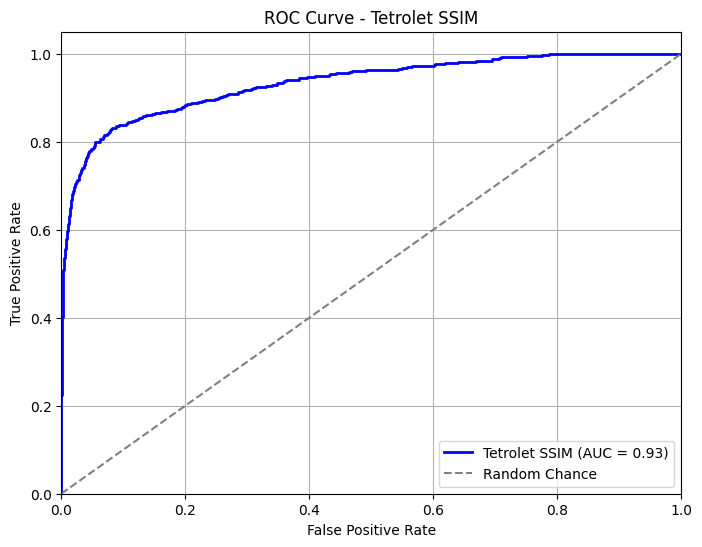

In [ ]:
# Install libraries if not already installed
!pip install pandas scikit-learn matplotlib openpyxl

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Step 1: Load your file
df = pd.read_csv('/content/Image_similarity_results (3) (1).csv')

# Step 2: Preprocess (clean 'Y/Predict' column)
df['Y/Predict'] = df['Y/Predict'].astype(str).str.strip().str.lower()

# Step 3: Map 'yes' -> 1, 'no' -> 0 for ground truth
df['Actual_Label'] = df['Y/Predict'].map({'yes': 1, 'no': 0})

# Step 4: T_Similarity as the prediction score
y_true = df['Actual_Label']
y_scores = df['T_Similarity']  # Higher similarity → more likely same class

# Step 5: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Step 6: Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Tetrolet SSIM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tetrolet SSIM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
plt.savefig('tetrolet_ssim_roc_curve.png')


<Figure size 640x480 with 0 Axes>

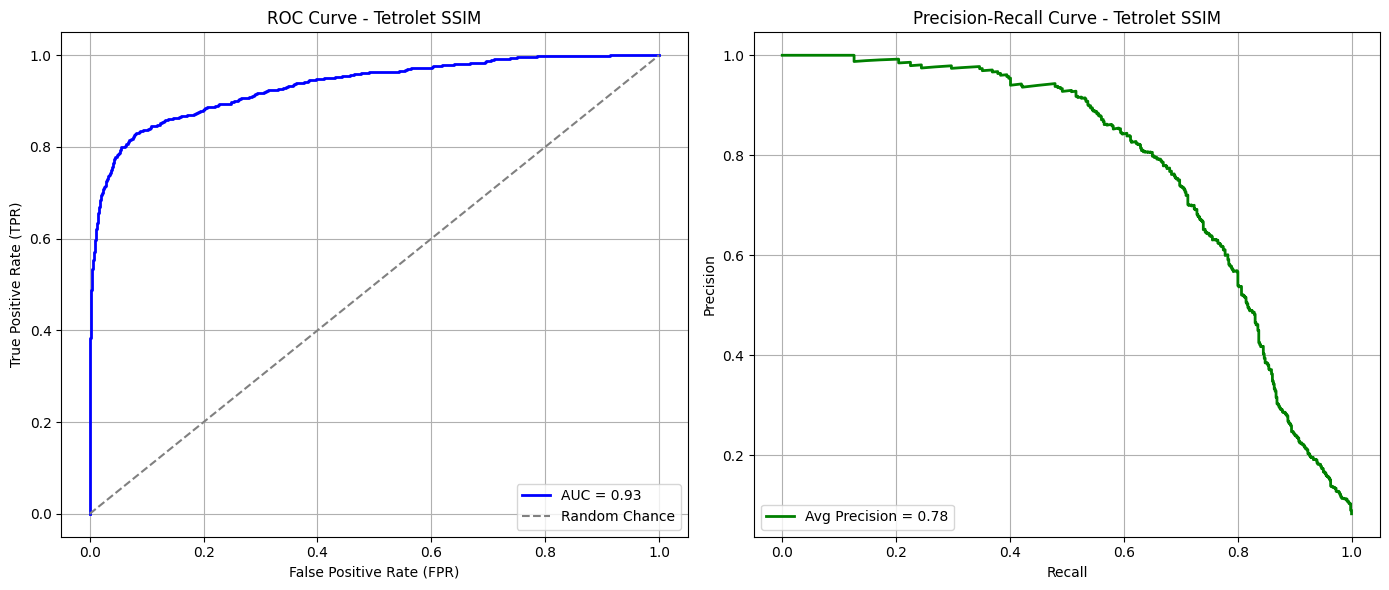

✅ Saved the plot at: /content/tetrolet_ssim_roc_pr_curves.png


In [ ]:
# Install libraries if not already installed
!pip install pandas scikit-learn matplotlib openpyxl

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Step 1: Load your file
df = pd.read_csv('/content/Image_similarity_results (3) (1).csv')

# Step 2: Preprocess
df['Y/Predict'] = df['Y/Predict'].astype(str).str.strip().str.lower()

# Map 'yes' -> 1, 'no' -> 0
df['Actual_Label'] = df['Y/Predict'].map({'yes': 1, 'no': 0})

# T_Similarity as the prediction score
y_true = df['Actual_Label']
y_scores = df['T_Similarity']

# Step 3: ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Step 4: Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

# Step 5: Plotting
plt.figure(figsize=(14, 6))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Tetrolet SSIM')
plt.legend(loc="lower right")
plt.grid(True)

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tetrolet SSIM')
plt.legend(loc="lower left")
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Step 6: Save the figure
plt.savefig('/content/tetrolet_ssim_roc_pr_curves.png', dpi=300)

# Step 7: Show it
plt.show()

print("✅ Saved the plot at: /content/tetrolet_ssim_roc_pr_curves.png")
